### Utility-Based Metrics
Standard metrics (MSE, MAE) ignore the importance of rare extreme delays.  
Following the imbalanced regression literature, we implement:

$$prec^\phi = \frac{\sum_i \phi(\hat{y}_i) \cdot \mathbf{1}[|y_i - \hat{y}_i| \leq \theta]}{\sum_i \phi(\hat{y}_i)}$$

$$rec^\phi = \frac{\sum_i \phi(y_i) \cdot \mathbf{1}[|y_i - \hat{y}_i| \leq \theta]}{\sum_i \phi(y_i)}$$

$$F_1^\phi = \frac{2 \cdot prec^\phi \cdot rec^\phi}{prec^\phi + rec^\phi}$$

Where $\theta$ is an acceptable error tolerance (default: 30 min).

In [1]:

import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
def utility_metrics(y_true, y_pred, phi_true, theta=30.0):
    """
    Utility-based precision, recall and F1 for imbalanced regression.

    Parameters
    ----------
    y_true  : true target values
    y_pred  : predicted values
    phi_true: relevance scores for y_true (rank-based, range 0-1)
    theta   : acceptable error tolerance in minutes (default 30)
    """
    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    phi     = np.array(phi_true)

    # phi for predictions (rank among predicted values)
    phi_pred = pd.Series(y_pred).rank(pct=True).values

    within_tolerance = (np.abs(y_true - y_pred) <= theta).astype(float)

    prec_denom = phi_pred.sum()
    rec_denom  = phi.sum()

    prec = (phi_pred * within_tolerance).sum() / prec_denom if prec_denom > 0 else 0.0
    rec  = (phi      * within_tolerance).sum() / rec_denom  if rec_denom  > 0 else 0.0
    f1   = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0

    return dict(prec_phi=prec, rec_phi=rec, f1_phi=f1)


def evaluate(model, X_t, y_t, phi_t, theta=30.0):
    preds = np.clip(model.predict(X_t), 0, None)

    # Standard metrics
    rmse = np.sqrt(mean_squared_error(y_t, preds))
    mae  = mean_absolute_error(y_t, preds)

    # Tail metrics — flights delayed > 60 min
    mask = y_t > 60
    tail_mae  = mean_absolute_error(y_t[mask], preds[mask]) if mask.sum() > 0 else np.nan
    tail_rmse = np.sqrt(mean_squared_error(y_t[mask], preds[mask])) if mask.sum() > 0 else np.nan

    # Phi-weighted MAE
    weighted_mae = (phi_t * (y_t - preds).abs()).sum() / phi_t.sum()

    # Utility-based metrics
    util = utility_metrics(y_t, preds, phi_t, theta=theta)

    return dict(
        RMSE=rmse, MAE=mae,
        Tail_RMSE=tail_rmse, Tail_MAE=tail_mae, tail_n=int(mask.sum()),
        Weighted_MAE=weighted_mae,
        **util
    )

In [2]:
import joblib

print("Loading data from disk...")
pipeline_inputs = joblib.load('pipeline_inputs.joblib')

datasets = pipeline_inputs['datasets']
X_test   = pipeline_inputs['X_test']
y_test   = pipeline_inputs['y_test']
phi_test = pipeline_inputs['phi_test']

print("Successfully loaded data!")

Loading data from disk...
Successfully loaded data!


### Model Definitions
- **Linear Regression** — baseline linear model  
- **SVR** — support vector regression (with scaling pipeline)  
- **Random Forest** — ensemble of decision trees  
- **LightGBM** — gradient boosted trees (extra benchmark)

### Training & Evaluation Loop
Each model is trained on every resampling strategy.  
WERCS passes φ as `sample_weight` where the model supports it (RF + LightGBM).

In [3]:
from datetime import datetime
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import lightgbm as lgb

THETA = 30.0  # acceptable error tolerance in minutes (φ-metrics)

all_results = {}  # (model_name, strategy) -> metrics dict
all_models  = {}  # (model_name, strategy) -> fitted model


def make_models():
    """Return fresh model instances to avoid state leakage between strategies."""
    return {
        'LinearRegression': LinearRegression(n_jobs=-1),
        'SVR': Pipeline([
            ('scaler', StandardScaler()),
            ('svr', SVR(kernel='rbf', C=5.0, epsilon=10.0, cache_size=10000))
        ]),
        'RandomForest': RandomForestRegressor(
            n_estimators=300,
            max_depth=20,
            min_samples_leaf=50,
            n_jobs=-1,
            random_state=42
        ),
        'LightGBM': lgb.LGBMRegressor(
            objective='regression_l1',
            n_estimators=600,
            learning_rate=0.05,
            num_leaves=127,
            min_child_samples=50,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
    }


def train_one_model(model_name, model, strategy, Xr, yr, phi_r):
    Xr = Xr.infer_objects()  # restore dtypes if corrupted by concat/iloc
    supports_weights = model_name in ('RandomForest', 'LightGBM')
    if strategy == 'WERCS' and supports_weights:
        model.fit(Xr, yr, sample_weight=phi_r)
    else:
        model.fit(Xr, yr)
    return model


def run_model_across_strategies(model_name, datasets, phi_test, theta=THETA):
    """
    Train one model across all resampling strategies with a progress bar.
    Updates all_results and all_models in place.
    """
    t0 = datetime.now()
    SAMPLE = 0.0001
    T_R = 0.80

    # Sample indices once from baseline (first dataset) — applied to all strategies
    first_Xr, first_yr = next(iter(datasets.values()))
    phi_first  = first_yr.rank(pct=True)
    rare_keep   = phi_first[phi_first >= T_R].index.to_series().sample(frac=SAMPLE, random_state=42).values
    normal_keep = phi_first[phi_first <  T_R].index.to_series().sample(frac=SAMPLE, random_state=42).values
    keep        = np.concatenate([rare_keep, normal_keep])

    bar = tqdm(datasets.items(), desc=f'{model_name}', leave=True)
    print(f"Started training {model_name}")

    for strategy, (Xr, yr) in bar:
        valid_keep = keep[keep < len(Xr)]
        Xr_fit = Xr.iloc[valid_keep].reset_index(drop=True).astype(Xr.dtypes.to_dict())
        yr_fit = yr.iloc[valid_keep].reset_index(drop=True)
        phi_r  = yr_fit.rank(pct=True)

        bar.set_postfix_str(f'{strategy} ({len(Xr_fit):,} / {len(Xr):,} rows)')

        model = make_models()[model_name]
        model = train_one_model(model_name, model, strategy, Xr_fit, yr_fit, phi_r)

        metrics = evaluate(model, X_test, y_test, phi_test, theta=theta)
        all_results[(model_name, strategy)] = metrics
        all_models[(model_name, strategy)]  = model

        print(
            f'  [{model_name}][{strategy}] '
            f"MAE={metrics['MAE']:.2f}  F1φ={metrics['f1_phi']:.4f}  "
            f"precφ={metrics['prec_phi']:.4f}  recφ={metrics['rec_phi']:.4f}"
        )

    elapsed = datetime.now() - t0
    print(f'  {model_name} done in {elapsed}\n')


### Training - LinearRegression
Baseline linear model. Fast to train; sets a lower-bound benchmark.

In [4]:
run_model_across_strategies('LinearRegression', datasets, phi_test, theta=THETA)

LinearRegression:   0%|          | 0/6 [00:00<?, ?it/s]

Started training LinearRegression


LinearRegression:  17%|█▋        | 1/6 [00:07<00:36,  7.36s/it, Baseline (241,061 / 24,106,081 rows)]

  [LinearRegression][Baseline] MAE=22.19  F1φ=0.8544  precφ=0.8908  recφ=0.8209


LinearRegression:  33%|███▎      | 2/6 [00:13<00:26,  6.74s/it, RU (144,910 / 14,467,121 rows)]      

...

  [LinearRegression][GaussNoise] MAE=41.45  F1φ=0.2017  precφ=0.1603  recφ=0.2718


LinearRegression:  83%|████████▎ | 5/6 [01:18<00:23, 23.18s/it, SMOTER (241,061 / 31,348,324 rows)]    

  [LinearRegression][SMOTER] MAE=22.06  F1φ=0.8539  precφ=0.8904  recφ=0.8202


LinearRegression: 100%|██████████| 6/6 [01:20<00:00, 13.45s/it, WERCS (241,061 / 28,927,297 rows)] 

  [LinearRegression][WERCS] MAE=26.74  F1φ=0.7785  precφ=0.7690  recφ=0.7882
  LinearRegression done in 0:01:23.540404



### Training - SVR
RBF kernel SVR. Wrapped in a StandardScaler pipeline. Slowest model — expect significant runtime on large data.

In [4]:
run_model_across_strategies('SVR', datasets, phi_test, theta=THETA)

SVR:   0%|          | 0/6 [00:00<?, ?it/s]

Started training SVR


SVR:  17%|█▋        | 1/6 [05:34<27:54, 334.89s/it, Baseline (2,411 / 24,106,081 rows)]

  [SVR][Baseline] MAE=20.16  F1φ=0.8401  precφ=0.8853  recφ=0.7994


SVR:  33%|███▎      | 2/6 [10:07<19:52, 298.02s/it, RU (1,463 / 14,467,121 rows)]      

...

  [SVR][GaussNoise] MAE=25.73  F1φ=0.7203  precφ=0.6930  recφ=0.7498


SVR:  83%|████████▎ | 5/6 [5:18:26<57:08, 3428.61s/it, SMOTER (2,411 / 31,348,324 rows)]      

  [SVR][SMOTER] MAE=20.14  F1φ=0.8397  precφ=0.8846  recφ=0.7992


SVR: 100%|██████████| 6/6 [5:25:06<00:00, 3251.05s/it, WERCS (2,411 / 28,927,297 rows)] 

  [SVR][WERCS] MAE=20.24  F1φ=0.8399  precφ=0.8835  recφ=0.8004
  SVR done in 5:25:08.777823



### Training - RandomForest
Ensemble of 300 decision trees. Supports WERCS sample weights natively.

In [10]:
run_model_across_strategies('RandomForest', datasets, phi_test, theta=THETA)

RandomForest:   0%|          | 0/6 [00:00<?, ?it/s, Baseline (241,061 / 24,106,081 rows)]

Started training RandomForest


RandomForest:  17%|█▋        | 1/6 [00:41<03:27, 41.42s/it, Baseline (241,061 / 24,106,081 rows)]

  [RandomForest][Baseline] MAE=21.36  F1φ=0.8186  precφ=0.8316  recφ=0.8060


RandomForest:  33%|███▎      | 2/6 [01:10<02:15, 33.88s/it, RU (144,910 / 14,467,121 rows)]      

...

  [RandomForest][GaussNoise] MAE=27.27  F1φ=0.6920  precφ=0.6505  recφ=0.7390


RandomForest:  83%|████████▎ | 5/6 [03:26<00:42, 42.94s/it, SMOTER (241,061 / 31,348,324 rows)]    

  [RandomForest][SMOTER] MAE=21.21  F1φ=0.8214  precφ=0.8361  recφ=0.8072


RandomForest: 100%|██████████| 6/6 [04:06<00:00, 41.05s/it, WERCS (241,061 / 28,927,297 rows)] 

  [RandomForest][WERCS] MAE=36.57  F1φ=0.3389  precφ=0.2627  recφ=0.4774
  RandomForest done in 0:04:08.272149



### Training - LightGBM
Gradient boosted trees. Extra benchmark — not in the original spec but useful for comparison.

In [9]:
run_model_across_strategies('LightGBM', datasets, phi_test, theta=THETA)

LightGBM:   0%|          | 0/6 [00:00<?, ?it/s, Baseline (241,061 / 24,106,081 rows)]

Started training LightGBM


LightGBM:  17%|█▋        | 1/6 [00:21<01:47, 21.45s/it, RU (144,910 / 14,467,121 rows)]      

  [LightGBM][Baseline] MAE=14.47  F1φ=0.7977  precφ=0.8445  recφ=0.7558


LightGBM:  33%|███▎      | 2/6 [00:43<01:27, 21.75s/it, RO (241,061 / 31,348,324 rows)]

...

  [LightGBM][GaussNoise] MAE=15.46  F1φ=0.8157  precφ=0.8541  recφ=0.7806


LightGBM:  83%|████████▎ | 5/6 [01:46<00:21, 21.23s/it, SMOTER (241,061 / 31,348,324 rows)]    

  [LightGBM][SMOTER] MAE=14.45  F1φ=0.7988  precφ=0.8463  recφ=0.7564


LightGBM: 100%|██████████| 6/6 [02:26<00:00, 24.34s/it, WERCS (241,061 / 28,927,297 rows)] 

  [LightGBM][WERCS] MAE=20.12  F1φ=0.7798  precφ=0.7754  recφ=0.7843
  LightGBM done in 0:02:28.098229



### Results Table

In [5]:
results_df = pd.DataFrame(all_results).T
results_df.index.names = ['Model', 'Strategy']
results_df = results_df[[
    'f1_phi', 'prec_phi', 'rec_phi',
    'Weighted_MAE', 'MAE', 'RMSE',
    'Tail_MAE', 'Tail_RMSE', 'tail_n'
]].sort_values('f1_phi', ascending=False)
results_df.round(4)

f1_phi  prec_phi  rec_phi  Weighted_MAE      MAE     RMSE  \
Model Strategy                                                                
SVR   RU          0.8415    0.8858   0.8014       29.6904  20.3558  51.0993   
      Baseline    0.8401    0.8853   0.7994       29.6381  20.1579  51.1507   
      WERCS       0.8399    0.8835   0.8004       29.6498  20.2412  51.1196   
      RO          0.8397    0.8846   0.7992       29.6303  20.1409  51.1527   
      SMOTER      0.8397    0.8846   0.7992       29.6303  20.1409  51.1527   
      GaussNoise  0.7203    0.6930   0.7498       31.8739  25.7292  51.2899   

                  Tail_MAE  Tail_RMSE    tail_n  
Model Strategy                                   
SVR   RU          131.2123   185.9649  425862.0  
      Baseline    131.7059   186.3100  425862.0  
      WERCS       131.4417   186.1305  425862.0  
      RO          131.7291   186.3294  425862.0  
      SMOTER      131.7291   186.3294  425862.0  
      GaussNoise  118.4442   177.6869  425862.0

### F₁φ Heatmap — Model × Strategy

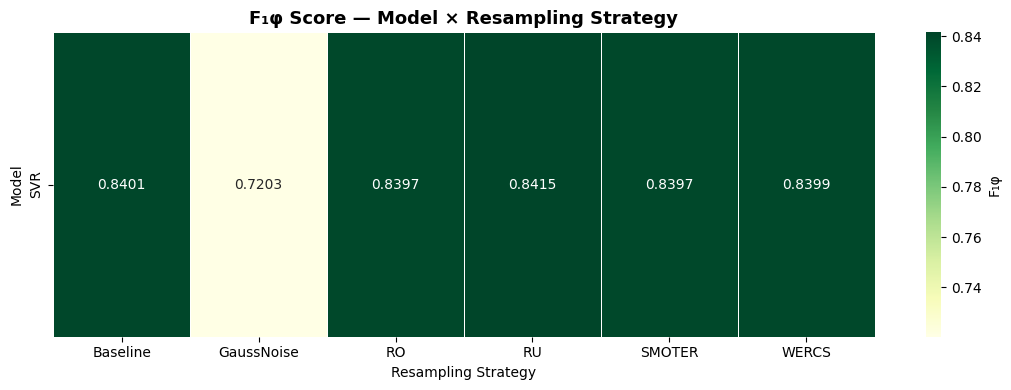

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
f1_pivot = results_df['f1_phi'].unstack(level='Strategy')

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    f1_pivot.astype(float),
    annot=True, fmt='.4f',
    cmap='YlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'F₁φ'}
)
ax.set_title('F₁φ Score — Model × Resampling Strategy', fontsize=13, weight='bold')
ax.set_xlabel('Resampling Strategy')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

### Precision & Recall φ — Grouped Bar Chart

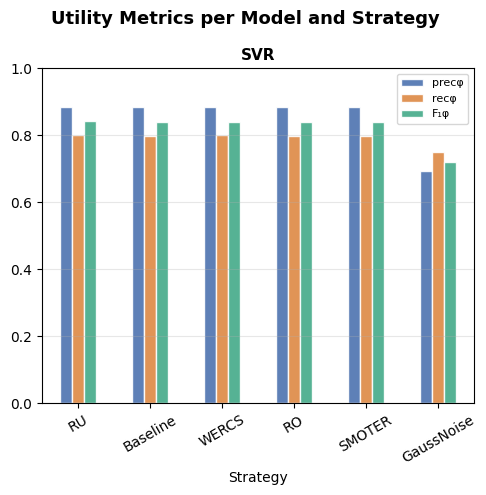

In [11]:
models_list     = results_df.index.get_level_values('Model').unique()
strategies_list = results_df.index.get_level_values('Strategy').unique()

fig, axes = plt.subplots(1, len(models_list), figsize=(5 * len(models_list), 5), sharey=True, squeeze=False)
axes = axes.flatten()

for ax, model_name in zip(axes, models_list):
    subset = results_df.loc[model_name][['prec_phi', 'rec_phi', 'f1_phi']]
    subset.plot.bar(ax=ax, color=['#4C72B0', '#dd8844', '#44aa88'],
                    edgecolor='white', alpha=0.9)
    ax.set_title(model_name, fontsize=11, weight='bold')
    ax.set_xlabel('Strategy')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(['precφ', 'recφ', 'F₁φ'], fontsize=8)

plt.suptitle('Utility Metrics per Model and Strategy', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

### Overall MAE Comparison

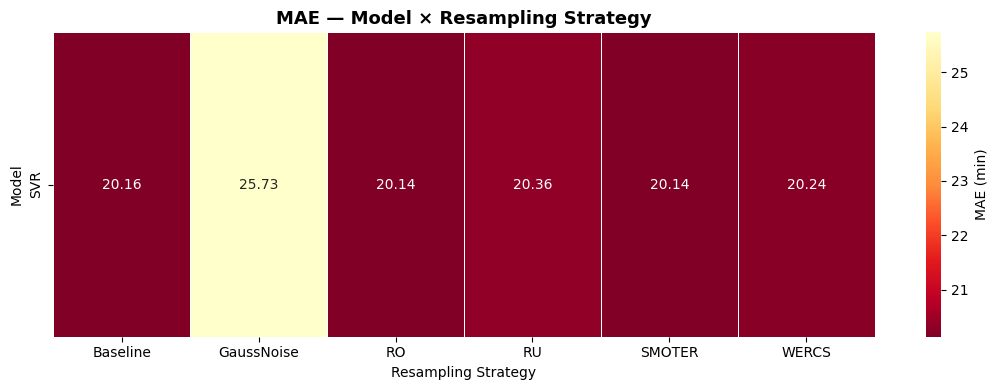

In [8]:
mae_pivot = results_df['MAE'].unstack(level='Strategy').astype(float)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    mae_pivot,
    annot=True, fmt='.2f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'MAE (min)'}
)
ax.set_title('MAE — Model × Resampling Strategy', fontsize=13, weight='bold')
ax.set_xlabel('Resampling Strategy')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

### Best Combination & Key Findings

In [9]:
best_idx     = results_df['f1_phi'].idxmax()
best_metrics = results_df.loc[best_idx]

print('=== Best combination by F₁φ ===')
print(f'  Model    : {best_idx[0]}')
print(f'  Strategy : {best_idx[1]}')
print(f'  F₁φ      : {best_metrics["f1_phi"]:.4f}')
print(f'  precφ    : {best_metrics["prec_phi"]:.4f}')
print(f'  recφ     : {best_metrics["rec_phi"]:.4f}')
print(f'  MAE      : {best_metrics["MAE"]:.2f} min')
print(f'  RMSE     : {best_metrics["RMSE"]:.2f} min')
print()

# Check article hypothesis: RF + WERCS should give best F1phi
rf_wercs_f1 = results_df.loc[('RandomForest', 'WERCS'), 'f1_phi']
print(f'RandomForest + WERCS F₁φ : {rf_wercs_f1:.4f}')
print(f'Hypothesis confirmed      : {best_idx == ("RandomForest", "WERCS")}')
print()

# Per-model best strategy
print('=== Best strategy per model (by F₁φ) ===')
for model_name in models_list:
    best_strat = results_df.loc[model_name, 'f1_phi'].idxmax()
    best_f1    = results_df.loc[(model_name, best_strat), 'f1_phi']
    print(f'  {model_name:<20}: {best_strat:<12}  F₁φ={best_f1:.4f}')

=== Best combination by F₁φ ===
  Model    : SVR
  Strategy : RU
  F₁φ      : 0.8415
  precφ    : 0.8858
  recφ     : 0.8014
  MAE      : 20.36 min
  RMSE     : 51.10 min



KeyError: ('RandomForest', 'WERCS')

In [ ]:
print(results_df.head())

### Feature Importance — Random Forest + WERCS

In [10]:
rf_wercs = all_models[('RandomForest', 'WERCS')]

fi = (
    pd.Series(rf_wercs.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(8, 6))
fi.sort_values().plot.barh(ax=ax, color='#44aa88', edgecolor='white')
ax.set_title('Top 20 Feature Importances — Random Forest + WERCS', fontsize=13, weight='bold')
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.grid(axis='x', alpha=0.35)
plt.tight_layout()
plt.show()

KeyError: ('RandomForest', 'WERCS')

### Residual Distributions — Best Model per Strategy

In [ ]:
# For each strategy, show residuals of the model with highest F1phi
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, strategy in zip(axes, strategies_list):
    best_model_name = results_df.xs(strategy, level='Strategy')['f1_phi'].idxmax()
    model = all_models[(best_model_name, strategy)]
    preds = np.clip(model.predict(X_test), 0, None)
    resid = y_test - preds

    ax.hist(resid, bins=80, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linewidth=1.2, linestyle='--')
    ax.set_title(f'{strategy}\n(best: {best_model_name})', fontsize=10, weight='bold')
    ax.set_xlabel('Residual (min)')
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Residual Distributions — Best Model per Strategy', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()